In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random

In [110]:
pd.read_csv("UDP.csv")
limit = 12000
dataset = []
for chunk in pd.read_csv('UDP-Data.csv',chunksize=100000):
    for row in chunk.itertuples(index=False,name = None):
        if (row[len(row)-2]!='Benign' and row[len(row)-2]!='DrDoS_UDP'):
            continue
        elif len(dataset)<limit :
            dataset.append(row)
        else:
            r = random.randint(0,len(dataset))
            if r<limit:
                dataset[r] = row
           
data = pd.DataFrame(dataset,columns=chunk.columns)         
dt = data.copy()
dt.head(10)

C:\Users\91959\AppData\Local\Temp\ipykernel_2956\1668135657.py:1: DtypeWarning: Columns (85) have mixed types. Specify dtype option on import or set low_memory=False.
  pd.read_csv("UDP.csv")


,Unnamed: 0,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Class
0,302833,17,47768,2,2,180.0,212.0,90.0,90.0,90.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
1,305776,17,20627,2,2,84.0,400.0,42.0,42.0,42.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
2,305902,6,162,1,2,0.0,0.0,0.0,0.0,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
3,300234,17,20742,2,2,86.0,118.0,43.0,43.0,43.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
4,304238,6,153,1,2,0.0,0.0,0.0,0.0,0.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
5,299221,17,20763,2,2,74.0,186.0,37.0,37.0,37.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
6,162946,17,20584,2,2,100.0,156.0,50.0,50.0,50.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
7,306144,17,45974,2,2,62.0,94.0,31.0,31.0,31.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
8,300104,17,20807,2,2,58.0,122.0,29.0,29.0,29.0000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign
9,304548,6,328215,14,14,4770.0,8412.0,1742.0,0.0,340.7143,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,Benign,Benign


In [111]:
k = dt[dt['Label']=='Benign']
#k[k['Label']!=k['Class']] #returns 0
k = dt[dt['Label']=='DrDoS_UDP']
k = k[k['Class']!='Attack']
#k.head(10) #returns 0 
# conclusion-> label and class is same just that label is subcategory of class therefore can remove it from above also

In [112]:
# for i in dt.columns:
#     print(i ,dt[i].value_counts()) 
# Total Backward Packets,Total Length of Bwd Packets ,Bwd Packet Length Max,Bwd Packet Length Min ,Bwd Packet Length Mean ,Bwd Packet Length Std 
# ,Bwd IAT Total,Bwd IAT Mean , Bwd IAT Std , Bwd IAT Max ,Bwd IAT Min,Fwd PSH Flags,Bwd PSH Flags ,Fwd URG Flags ,Bwd URG Flags ,Bwd Header Length 
# ,Bwd Packets/s ,FIN Flag Count ,SYN Flag Count,RST Flag Count,PSH Flag Count,ACK Flag Count,URG Flag Count ,CWE Flag Count,ECE Flag Count 
# ,Down/Up Ratio,Avg Bwd Segment Size ,Fwd Avg Bytes/Bulk, Fwd Avg Packets/Bulk ,Fwd Avg Bulk Rate ,Bwd Avg Bytes/Bulk ,Bwd Avg Packets/Bulk 
# ,Bwd Avg Bulk Rate, Subflow Bwd Packets ,Subflow Bwd Bytes ,Init_Win_bytes_forward ,Init_Win_bytes_backward ,Active Mean ,Active Std,Active Max ,Active Min,
# Idle Mean,Idle Std, Idle Max,Idle Min,SimillarHTTP,

In [113]:
dt['Label'].value_counts()

Label
Benign       10857
DrDoS_UDP     1143
Name: count, dtype: int64

In [114]:
dt.columns

Index(['Unnamed: 0', 'Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags',
       'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Co

In [132]:
dt.drop([
    'Class',
    'Fwd URG Flags', 'Bwd URG Flags',
    'Unnamed: 0','PSH Flag Count','FIN Flag Count','Bwd PSH Flags',
    'Fwd Avg Bytes/Bulk', 'Fwd Avg Packets/Bulk', 'Fwd Avg Bulk Rate',
       'Bwd Avg Bytes/Bulk', 'Bwd Avg Packets/Bulk', 'Bwd Avg Bulk Rate'
], axis=1, inplace=True,errors='ignore')


In [133]:
numeric = list()
category = list()
for i in dt.columns:
    if str(data[i].dtype)=='float64' or str(data[i].dtype)=='int64':
        numeric.append(i)
    else:
        category.append(i)
len(numeric)

66

In [134]:
dt.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9718 entries, 0 to 11998
Data columns (total 67 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Protocol                  9718 non-null   int64  
 1   Flow Duration             9718 non-null   int64  
 2   Total Fwd Packets         9718 non-null   int64  
 3   Total Backward Packets    9718 non-null   int64  
 4   Fwd Packets Length Total  9718 non-null   float64
 5   Bwd Packets Length Total  9718 non-null   float64
 6   Fwd Packet Length Max     9718 non-null   float64
 7   Fwd Packet Length Min     9718 non-null   float64
 8   Fwd Packet Length Mean    9718 non-null   float64
 9   Fwd Packet Length Std     9718 non-null   float64
 10  Bwd Packet Length Max     9718 non-null   float64
 11  Bwd Packet Length Min     9718 non-null   float64
 12  Bwd Packet Length Mean    9718 non-null   float64
 13  Bwd Packet Length Std     9718 non-null   float64
 14  Flow Bytes/s

In [130]:
# fig,ax = plt.subplots(33,2,figsize = (15,200))
# k=0;
# for i in range(0,33):
#     for j in range(0,2):
#         ax[i,j].plot(dt[numeric[k]])
#         ax[i,j].set_title(numeric[k])
#         k+=1;

# plt.show()

In [136]:
dt.columns


Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count',
       'RST Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count',
       'ECE 

In [138]:
numeric_data = pd.DataFrame(dt,columns=numeric)
categorical_data = pd.DataFrame(dt,columns=category)
numeric_data.shape

(9718, 66)

**HANDLE OUTLIERS**

In [139]:
# find outliers - by univariate,bivariate analysis
# fig, axes = plt.subplots(33, 2, figsize=(15, 100))
# for i, column in enumerate(numeric_data.columns):
#     sns.kdeplot(numeric_data[column], ax=axes.flat[i])
#     m=numeric_data[column].mean()
#     axes.flat[i].axvline(m,color='red')
#     axes.flat[i].set_title(column)

# plt.tight_layout()
# plt.show()
#outliers-flow duration,fwd packet length min/max/std/mean,Bwd packet length,flow iat std/max/fwd packets and packet length min,ack/rst flag count
#ideal min/max..all,init fwd/bwd win packets - although show little but still better to narrow down them

**OUTLIER HANDLING**

In [140]:
def outlier_removal(a,col):
    q1 = a[col].quantile(0.25)
    q3 = a[col].quantile(0.75)
    iqr = q3-q1
    lower = q1 - 1.5*iqr
    upper = q3 + 1.5*iqr
    return a[(a[col]>=lower) & (a[col]<=upper)]
    

In [141]:
#Flow Duration
dt = outlier_removal(dt,'Flow Duration')
dt.shape

(9000, 67)

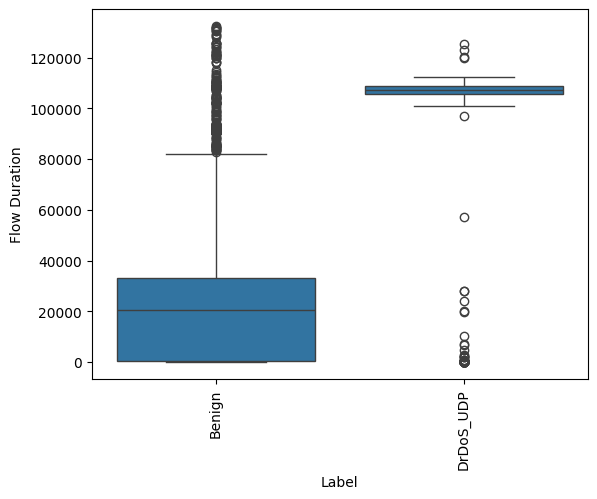

In [142]:
#FWD Packet Length min/max/std/mean
sns.boxplot(data=dt,x='Label',y='Flow Duration')
plt.xticks(rotation=90)
plt.show()
#conclusion-> Ddos actually happens for higher flow duration time

In [143]:
dt.groupby('Label')['Fwd Packet Length Min'].describe()

,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
Benign,8251.0,23.027754,50.498219,0.0,0.0,29.0,41.0,2020.0
DrDoS_UDP,749.0,339.664887,51.544577,236.0,330.0,330.0,330.0,1472.0


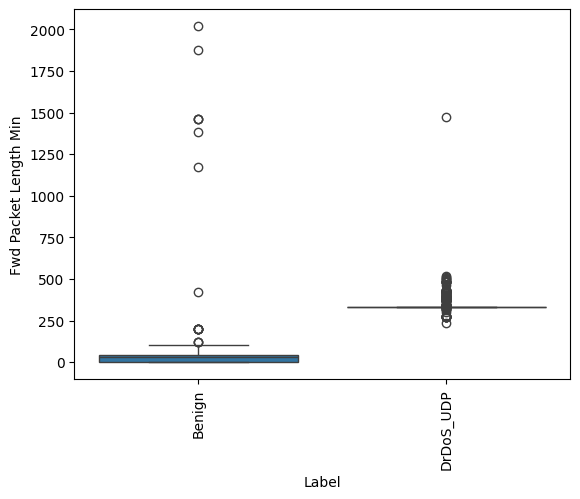

In [144]:
sns.boxplot(data=dt,x='Label',y='Fwd Packet Length Min')
plt.xticks(rotation=90)
plt.show()

In [145]:
numeric_data.shape

(9718, 66)

In [148]:
dt = dt[dt['Fwd Packet Length Min']<=1100]
dt.columns

Index(['Protocol', 'Flow Duration', 'Total Fwd Packets',
       'Total Backward Packets', 'Fwd Packets Length Total',
       'Bwd Packets Length Total', 'Fwd Packet Length Max',
       'Fwd Packet Length Min', 'Fwd Packet Length Mean',
       'Fwd Packet Length Std', 'Bwd Packet Length Max',
       'Bwd Packet Length Min', 'Bwd Packet Length Mean',
       'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s',
       'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max',
       'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std',
       'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Fwd Header Length',
       'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s',
       'Packet Length Min', 'Packet Length Max', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'SYN Flag Count',
       'RST Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count',
       'ECE 

In [149]:
#Fwd Packet Length Max
dt.groupby('Label')['Fwd Packet Length Max'].describe()


,count,mean,std,min,25%,50%,75%,max
Label,,,,,,,,
Benign,8244.0,43.865721,145.428350,0.0,0.0,32.0,43.0,3139.0
DrDoS_UDP,748.0,382.691176,23.618727,316.0,369.0,386.0,389.0,520.0


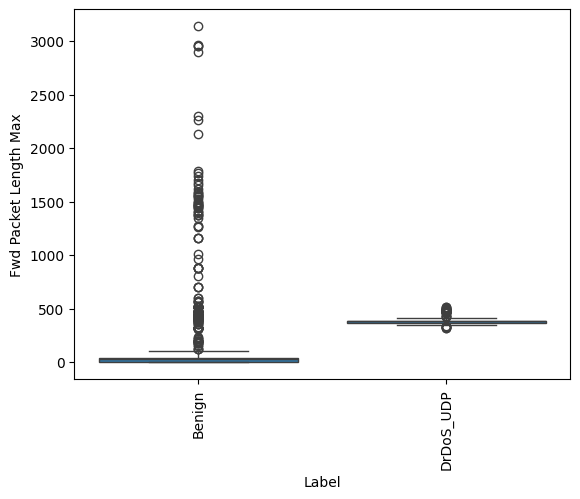

In [152]:
sns.boxplot(
    data=dt,
    x ='Label',
    y = "Fwd Packet Length Max"
)
plt.xticks(rotation=90)
plt.show()

**FEATURE SCALING**|

In [13]:
from mlxtend.feature_selection import ExhaustiveFeatureSelector as efs
